# LightGBM

In [33]:
import lightgbm as lgb

print(lgb.__version__) 

%load_ext autoreload
%autoreload 2

4.6.0
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# создаем dummy-dataset
import numpy as np, pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=10_000, n_features=100, n_informative=60, random_state=911)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.23, shuffle=True, random_state=911)

tr = pd.DataFrame(X_tr, columns=['f_' + str(i) for i in range(X_tr.shape[1])], dtype=np.float32).assign(target=y_tr)
val = pd.DataFrame(X_val, columns=['f_' + str(i) for i in range(X_val.shape[1])], dtype=np.float32).assign(target=y_val)

features = tr.columns.drop('target')

tr.info()
tr.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7700 entries, 0 to 7699
Columns: 101 entries, f_0 to target
dtypes: float32(100), int32(1)
memory usage: 3.0 MB


,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_91,f_92,f_93,f_94,f_95,f_96,f_97,f_98,f_99,target
0,-7.693210,-2.307856,1.330482,1.956519,-4.737048,-0.808857,-0.083493,-0.652450,-0.827025,2.895884,...,1.932500,-2.487015,0.531025,0.015999,3.841881,2.944531,-5.108033,-3.738099,0.668487,1
1,3.562736,2.726196,0.833317,0.382781,3.403235,0.835908,1.004829,2.453187,0.384746,0.400144,...,0.999936,0.831185,-8.842968,0.722457,6.440717,7.990329,-6.200291,2.575604,0.239539,0
2,1.181314,5.904849,0.574240,-1.499972,-2.565058,1.321400,-0.385923,4.773221,-0.879839,0.423675,...,-12.167426,-0.476589,-4.122464,-0.155873,-7.015498,0.609455,0.688230,-10.570615,-0.753206,1


### 1. sample code - делаем модельку

In [3]:
tr_lgb = lgb.Dataset(tr[features], tr.target)
val_lgb = lgb.Dataset(val[features], val.target)

params = {
    'objective': 'binary',
    'eta': 0.2,
    
    'metric': 'auc',
    'nthread': 32,
    'verbose': 0,
    'seed': 911
}

model = lgb.train(
    params, tr_lgb, num_boost_round=600,
    valid_sets=[val_lgb], callbacks=[lgb.early_stopping(20), lgb.log_evaluation(41)] # настройка early_stopping
)

y_raw = model.predict(val[features], raw_score=True) # так делать надо
y_prob = model.predict(val[features], raw_score=False) # по умолчанию False, но так делать не надо
print('y_raw:', y_raw[:5], '\ny_prob:', y_prob[:10].round(3))

Training until validation scores don't improve for 20 rounds
[41]	valid_0's auc: 0.965945
[82]	valid_0's auc: 0.976337
[123]	valid_0's auc: 0.981041
[164]	valid_0's auc: 0.98365
[205]	valid_0's auc: 0.984564
[246]	valid_0's auc: 0.985468
[287]	valid_0's auc: 0.986568
[328]	valid_0's auc: 0.986944
Early stopping, best iteration is:
[347]	valid_0's auc: 0.98721
y_raw: [-9.84991786  5.5639161  -6.75092681 16.05469397 -7.47068601] 
y_prob: [0.    0.996 0.001 1.    0.001 1.    0.    0.    0.    0.022]


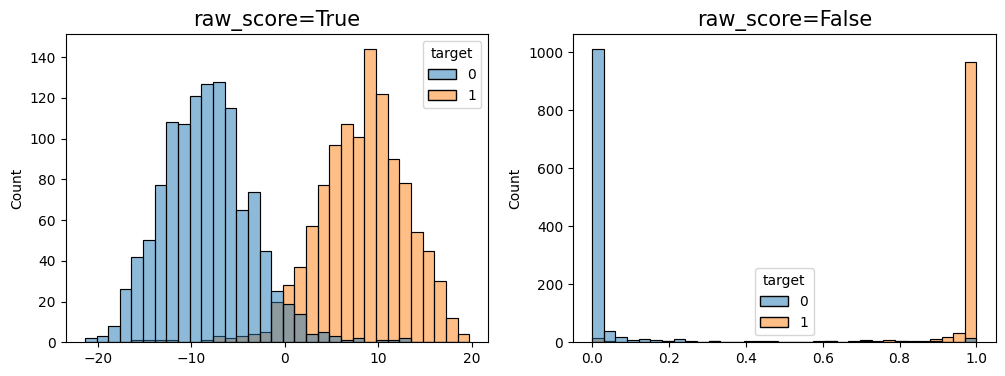

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].set_title('raw_score=True', fontsize=15)
sns.histplot(x=y_raw, hue=val.target, bins=33, ax=ax[0])
ax[1].set_title('raw_score=False', fontsize=15)
_ = sns.histplot(x=y_prob, hue=val.target, bins=33, ax=ax[1]) # log шкала спасает?


### 2. GOSS - работает ли?

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:36<00:00,  6.04s/it]


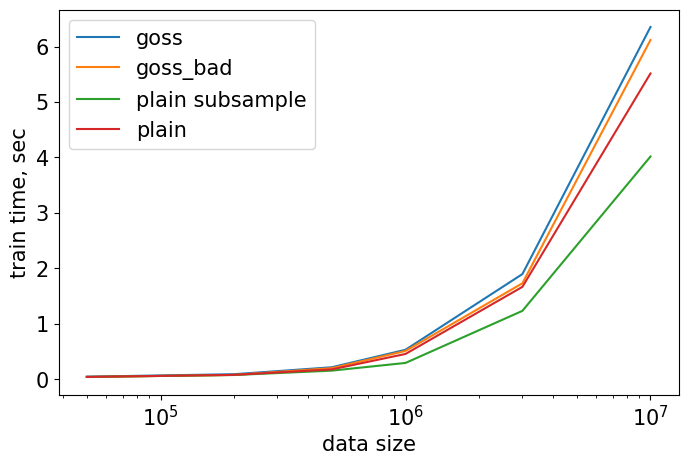

In [15]:
from local_utils import make_subsample_test

make_subsample_test()

И так уже третий год =)

### 3. linear_tree=True - насколько это быстро?

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:09<00:00,  1.53s/it]


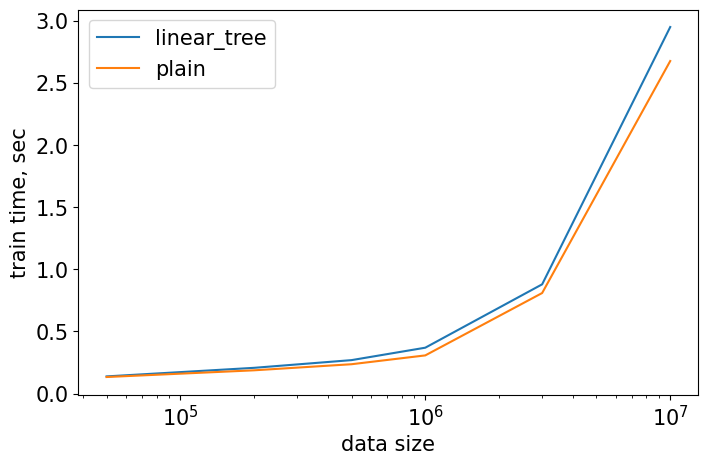

In [22]:
from local_utils import make_linear_tree_test

make_linear_tree_test()

Это быстро)

### 4. quantized_grad=True - работает ли?

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:08<00:00,  1.50s/it]


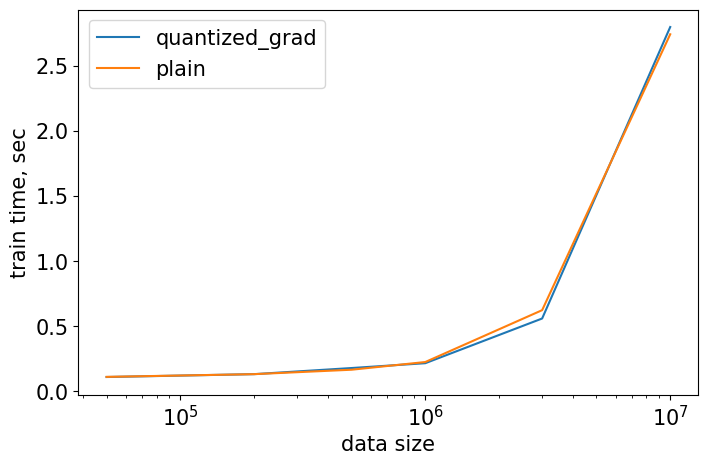

In [17]:
from local_utils import make_quantized_grad_test

make_quantized_grad_test()

Не особо)

### 5. DART - насколько это быстро?

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:13<00:00, 12.31s/it]


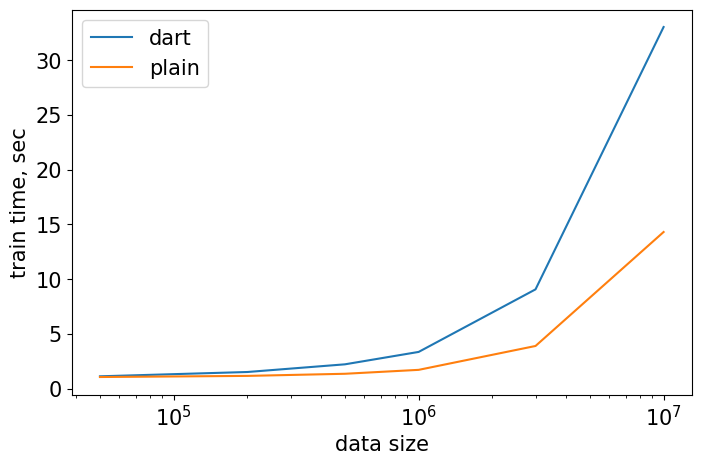

In [25]:
from local_utils import make_dart_test

make_dart_test()

Не особо)

### 6. eta - шокирующая правда!

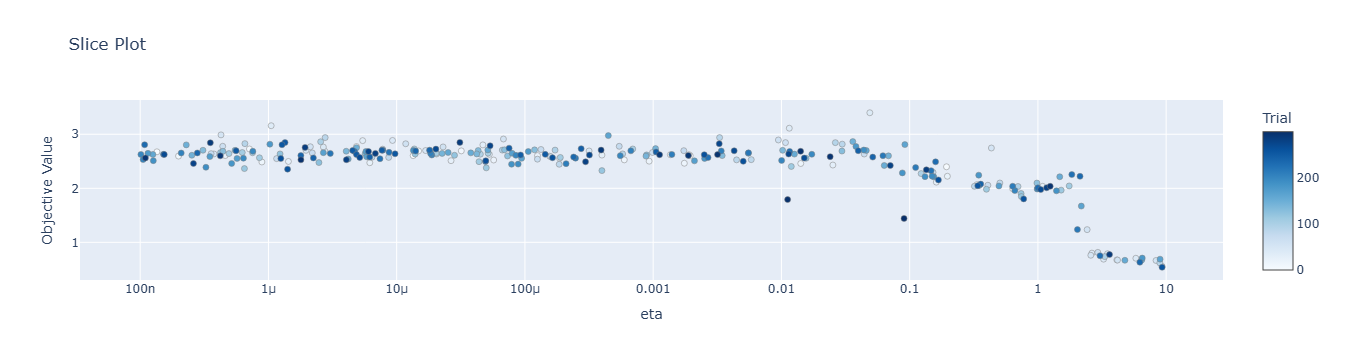

In [32]:
from local_utils import make_eta_test
from optuna.visualization import plot_slice

# 0.005, 1
study = make_eta_test()
plot_slice(study)